# Two-site Hubbard model from first principles

**Goal.** Understand every layer of a small correlated-fermion calculation before using `FermiHubbardModel`, `JordanWignerMapper`, or a packaged VQE. We will independently construct the fermionic and qubit Hamiltonians, prove numerically that they agree, solve the model exactly, and run a small manual VQE.

By the end of the notebook, we will have:

1. constructed the Fock basis and fermionic creation/annihilation matrices;
2. built and exactly diagonalized the Hubbard Hamiltonian at half filling;
3. derived the Jordan--Wigner (JW) operators from Pauli matrices;
4. decomposed the Hamiltonian into Pauli strings and checked it against the fermionic matrix;
5. minimized the Pauli expectation value with a symmetry-preserving variational circuit.


## 1. Model and conventions

The open two-site Hubbard Hamiltonian is

$$
H=-t(c_{0\uparrow}^\dagger c_{1\uparrow}+c_{1\uparrow}^\dagger c_{0\uparrow}+c_{0\downarrow}^\dagger c_{1\downarrow}+c_{1\downarrow}^\dagger c_{0\downarrow})+U(n_{0\uparrow} n_{0\downarrow}+n_{1\uparrow} n_{1\downarrow}).
$$

We use four spin orbitals in the fixed order

$$p=0:(0,\uparrow),\quad p=1:(1,\uparrow),\quad
p=2:(0,\downarrow),\quad p=3:(1,\downarrow).$$
(follow Qiskit Nature's blocked spin-ordering convention)
A basis state is written as $|n_0n_1n_2n_3\rangle$. We work at half filling, $N=2$, and set $t=1$ as the energy unit unless stated otherwise.


In [4]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

np.set_printoptions(precision=6, suppress=True)

N_ORBITALS = 4
DIM = 2**N_ORBITALS
t = 1.0
U = 4.0

## 2. Fock basis and fermionic signs

For our ordering, fermionic annihilation acts as

$$a_p|n_0\ldots n_p\ldots\rangle=(-1)^{\sum_{q<p}n_q}
n_p|n_0\ldots 0_p\ldots\rangle.$$

The phase counts occupied orbitals preceding $p$. We implement that rule directly, with no fermion library.


In [7]:
def occupations(index, n_orbitals=N_ORBITALS):
    """Return occupations [n_0, ..., n_(M-1)] for a basis index."""
    return tuple((index >> p) & 1 for p in range(n_orbitals))


def ket_label(index):
    return "|" + "".join(map(str, occupations(index))) + "⟩"


def apply_annihilation(index, p):
    """Return (new_index, phase), or None when orbital p is empty."""
    occ = occupations(index)
    if occ[p] == 0:
        return None
    phase = (-1) ** sum(occ[:p])
    return index ^ (1 << p), phase


def annihilation_matrix(p):
    matrix = np.zeros((DIM, DIM), dtype=complex)
    for column in range(DIM):
        result = apply_annihilation(column, p)
        if result is not None:
            row, phase = result
            matrix[row, column] = phase
    return matrix

# annihilation operator
annihilators = [annihilation_matrix(p) for p in range(N_ORBITALS)]
# creation operator
creators = [c.conj().T for c in annihilators]
number_ops = [creators[p] @ annihilators[p] for p in range(N_ORBITALS)]

print("index  state    occ. N")
for index in range(DIM):
    print(f"{index:>2}     {ket_label(index)}     {sum(occupations(index))}")

index  state    occ. N
 0     |0000⟩     0
 1     |1000⟩     1
 2     |0100⟩     1
 3     |1100⟩     2
 4     |0010⟩     1
 5     |1010⟩     2
 6     |0110⟩     2
 7     |1110⟩     3
 8     |0001⟩     1
 9     |1001⟩     2
10     |0101⟩     2
11     |1101⟩     3
12     |0011⟩     2
13     |1011⟩     3
14     |0111⟩     3
15     |1111⟩     4


The defining canonical anticommutation relations (CAR) are $\{c_p,c_q^\dagger\}=\delta_{pq}I$ and $\{c_p,c_q\}=0$. They are a stringent unit test for both the bit convention and the fermionic phase.

In [8]:
identity = np.eye(DIM)
for p in range(N_ORBITALS):
    for q in range(N_ORBITALS):
        expected = identity if p == q else np.zeros_like(identity)
        assert np.allclose(annihilators[p] @ creators[q] + creators[q] @ annihilators[p], expected)
        assert np.allclose(annihilators[p] @ annihilators[q] + annihilators[q] @ annihilators[p], 0)
print("✓ Canonical anticommutation relations verified")

✓ Canonical anticommutation relations verified


## 3. Construct the Hubbard Hamiltonian

The hopping pairs are $(0,1)$ for spin up and $(2,3)$ for spin down. The interaction is diagonal and penalizes double occupancy on each site. We also construct $N=\sum_p n_p$ and verify particle-number conservation.


In [9]:
def hubbard_hamiltonian(t, U):
    hopping = np.zeros((DIM, DIM), dtype=complex)
    # up hopping: 0 and 1
    # down hopping: 2 and 3
    for left, right in [(0, 1), (2, 3)]:
        hopping += creators[left] @ annihilators[right]
        hopping += creators[right] @ annihilators[left]
    # site 0 interaction: 0 and 2
    # site 1 interaction: 1 and 3
    interaction = number_ops[0] @ number_ops[2] + number_ops[1] @ number_ops[3]
    return -t * hopping + U * interaction


H_fermion = hubbard_hamiltonian(t, U)
N_op = sum(number_ops)

assert np.allclose(H_fermion, H_fermion.conj().T)
assert np.allclose(H_fermion @ N_op - N_op @ H_fermion, 0)
print("✓ H is Hermitian and [H, N] = 0")

print("Nonzero off-diagonal matrix elements H[row, column]:")
rows, cols = np.where(np.triu(np.abs(H_fermion), k=1) > 1e-12)
for row, col in zip(rows, cols):
    print(f"  {ket_label(row):8s} ↔ {ket_label(col):8s}: {H_fermion[row, col].real:+.1f}")

✓ H is Hermitian and [H, N] = 0
Nonzero off-diagonal matrix elements H[row, column]:
  |1000⟩   ↔ |0100⟩  : -1.0
  |0010⟩   ↔ |0001⟩  : -1.0
  |1010⟩   ↔ |0110⟩  : -1.0
  |1010⟩   ↔ |1001⟩  : -1.0
  |0110⟩   ↔ |0101⟩  : -1.0
  |1110⟩   ↔ |1101⟩  : -1.0
  |1001⟩   ↔ |0101⟩  : -1.0
  |1011⟩   ↔ |0111⟩  : -1.0


## 4. Exact diagonalization at half filling

Because $[H,N]=0$, the six $N=2$ determinants form an invariant sector. Restricting to it removes irrelevant vacuum, one-particle, and other filling sectors. For this two-site problem the exact half-filled ground-state energy is

$$E_0=\frac{U-\sqrt{U^2+16t^2}}{2},$$

which gives an independent analytic check.


In [10]:
half_filling = [i for i in range(DIM) if sum(occupations(i)) == 2]
H_half = H_fermion[np.ix_(half_filling, half_filling)]
energies, eigenvectors = np.linalg.eigh(H_half)
E_exact = energies[0]
psi_exact = np.zeros(DIM, dtype=complex)
psi_exact[half_filling] = eigenvectors[:, 0]
E_analytic = (U - np.sqrt(U**2 + 16 * t**2)) / 2

assert np.isclose(E_exact, E_analytic)
print("N=2 basis:", [ket_label(i) for i in half_filling])
print("N=2 spectrum:", np.round(energies, 8))
print(f"ground energy: numerical={E_exact:.10f}, analytic={E_analytic:.10f}")
print()
print("Ground-state amplitudes (global phase is arbitrary):")
for index, amplitude in enumerate(psi_exact):
    if abs(amplitude) > 1e-10:
        print(f"  {ket_label(index):8s}: {amplitude.real:+.6f}")

N=2 basis: ['|1100⟩', '|1010⟩', '|0110⟩', '|1001⟩', '|0101⟩', '|0011⟩']
N=2 spectrum: [-0.828427  0.        0.        0.        4.        4.828427]
ground energy: numerical=-0.8284271247, analytic=-0.8284271247

Ground-state amplitudes (global phase is arbitrary):
  |1010⟩  : -0.270598
  |0110⟩  : -0.653281
  |1001⟩  : -0.653281
  |0101⟩  : -0.270598


### Ground-state observables

We measure total double occupancy $D=\sum_i\langle n_{i\uparrow}n_{i\downarrow}\rangle$ and the inter-site spin correlation $\langle\mathbf S_0\cdot\mathbf S_1\rangle$. The transverse spin terms must retain fermionic ordering:
$S_i^+=c^\dagger_{i\uparrow}c_{i\downarrow}$ and $S_i^-=c^\dagger_{i\downarrow}c_{i\uparrow}$.


In [11]:
double_occupancy_op = number_ops[0] @ number_ops[2] + number_ops[1] @ number_ops[3]
Sz0 = 0.5 * (number_ops[0] - number_ops[2])
Sz1 = 0.5 * (number_ops[1] - number_ops[3])
Sp0, Sm0 = creators[0] @ annihilators[2], creators[2] @ annihilators[0]
Sp1, Sm1 = creators[1] @ annihilators[3], creators[3] @ annihilators[1]
spin_correlation_op = Sz0 @ Sz1 + 0.5 * (Sp0 @ Sm1 + Sm0 @ Sp1)

def expectation(state, operator):
    return np.vdot(state, operator @ state).real


D_exact = expectation(psi_exact, double_occupancy_op)
S_exact = expectation(psi_exact, spin_correlation_op)
print(f"total double occupancy = {D_exact:.8f}")
print(f"<S_0 · S_1>           = {S_exact:.8f}")

total double occupancy = 0.14644661
<S_0 · S_1>           = -0.64016504


## 5. Manual Jordan--Wigner transformation

With occupied qubit state $|1\rangle$, the JW map in our ordering is

$$c_p=\left(\prod_{q<p}Z_q\right)\frac{X_p+iY_p}{2},\qquad
c_p^\dagger=\left(\prod_{q<p}Z_q\right)\frac{X_p-iY_p}{2}.$$

The $Z$ string reproduces the fermionic sign. NumPy's Kronecker-product order below is $q_3\otimes q_2\otimes q_1\otimes q_0$, so vector indices still match the Fock indices used above.


Because the two orbitals belonging to each hopping pair are
adjacent in this ordering, the hopping terms produce two-qubit
$XX$ and $YY$ strings without an intermediate Jordan--Wigner
$Z$ string. The interaction pairs are no longer adjacent, but
number operators map only to $I$ and $Z$, so no parity string
is needed for them.

In [12]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}


def operator_on_qubit(single_qubit_op, qubit):
    factors = [single_qubit_op if q == qubit else I2 for q in reversed(range(N_ORBITALS))]
    result = factors[0]
    for factor in factors[1:]:
        result = np.kron(result, factor)
    return result


Xq = [operator_on_qubit(X, p) for p in range(N_ORBITALS)]
Yq = [operator_on_qubit(Y, p) for p in range(N_ORBITALS)]
Zq = [operator_on_qubit(Z, p) for p in range(N_ORBITALS)]


def jw_annihilator(p):
    z_string = np.eye(DIM, dtype=complex)
    for q in range(p):
        z_string = z_string @ Zq[q]
    return z_string @ (Xq[p] + 1j * Yq[p]) / 2


jw_annihilators = [jw_annihilator(p) for p in range(N_ORBITALS)]
for p in range(N_ORBITALS):
    assert np.allclose(jw_annihilators[p], annihilators[p])
print("✓ Every manual JW annihilator equals its Fock-space matrix")

✓ Every manual JW annihilator equals its Fock-space matrix


## 6. Pauli Hamiltonian

Every four-qubit operator has an expansion $H=\sum_P h_P P$, with
$h_P=2^{-4}\operatorname{Tr}(P^\dagger H)$. We deliberately compute all coefficients rather than asking a mapper. Labels are printed as $q_3q_2q_1q_0$, matching the matrix Kronecker order.


In [13]:
def pauli_matrix(label):
    result = PAULI[label[0]]
    for symbol in label[1:]:
        result = np.kron(result, PAULI[symbol])
    return result


def pauli_decomposition(operator, atol=1e-12):
    terms = {}
    for symbols in itertools.product("IXYZ", repeat=N_ORBITALS):
        label = "".join(symbols)  # q3 q2 q1 q0
        matrix = pauli_matrix(label)
        coefficient = np.trace(matrix.conj().T @ operator) / DIM
        if abs(coefficient) > atol:
            terms[label] = np.real_if_close(coefficient).item()
    return terms


pauli_terms = pauli_decomposition(H_fermion)
for label, coefficient in pauli_terms.items():
    print(f"{coefficient.real:+.6f}  {label}")

H_pauli = sum(coefficient * pauli_matrix(label) for label, coefficient in pauli_terms.items())
assert np.allclose(H_pauli, H_fermion)
print()
print(f"✓ Pauli reconstruction matches H ({len(pauli_terms)} nonzero strings)")

+2.000000  IIII
-1.000000  IIIZ
-0.500000  IIXX
-0.500000  IIYY
-1.000000  IIZI
-1.000000  IZII
+1.000000  IZIZ
-0.500000  XXII
-0.500000  YYII
-1.000000  ZIII
+1.000000  ZIZI

✓ Pauli reconstruction matches H (11 nonzero strings)



For example, $n_p=(I-Z_p)/2$, so each on-site interaction produces $U(I-Z_{i\uparrow})(I-Z_{i\downarrow})/4$. Because the same-spin orbitals are adjacent in the spin-block ordering, the hopping terms produce $XX$ and $YY$ strings without an intermediate Jordan–Wigner $Z$ string.

## 7. A transparent symmetry-preserving variational circuit

The ground state has $N=2$ and $S_z=0$, so only four determinants are needed:
$|1010\rangle,|1001\rangle,|0110\rangle,|0101\rangle$. We use a sequence of **two-level rotations**. A gate $R_{ab}(\theta)$ acts only on determinants $|a\rangle,|b\rangle$:

$$R_{ab}(\theta)|a\rangle=\cos\theta|a\rangle+\sin\theta|b\rangle,\quad
R_{ab}(\theta)|b\rangle=-\sin\theta|a\rangle+\cos\theta|b\rangle.$$

Starting from $|1010\rangle$, three such gates can prepare any real normalized state in this four-dimensional symmetry sector (apart from coordinate singularities). The Hubbard ground state can be chosen real. This is a logical variational circuit: it makes expressibility and symmetry exact; decomposing these gates into hardware-native gates is deferred to the algorithm-design stage.


In [19]:
symmetry_basis = [5, 9, 6, 10]  # |1010>, |1001>, |0110>, |0101>


def two_level_rotation(state, a, b, theta):
    """Apply a real unitary rotation in span{|a>, |b>}."""
    result = state.copy()
    ca, cb = state[a], state[b]
    result[a] = np.cos(theta) * ca - np.sin(theta) * cb
    result[b] = np.sin(theta) * ca + np.cos(theta) * cb
    return result


def variational_state(theta):
    state = np.zeros(DIM, dtype=complex)
    state[symmetry_basis[0]] = 1.0
    for target, angle in zip(symmetry_basis[1:], theta):
        state = two_level_rotation(state, symmetry_basis[0], target, angle)
    return state


trial = variational_state([0.2, -0.4, 0.7])
assert np.isclose(np.vdot(trial, trial), 1)
assert np.isclose(expectation(trial, N_op), 2)
print("✓ Ansatz is normalized and preserves N=2 exactly")

✓ Ansatz is normalized and preserves N=2 exactly


## 8. Manual VQE loop

A VQE iteration has only three essential pieces: prepare $|\psi(\theta)\rangle$, measure each Pauli expectation $\langle P\rangle$, and let a classical optimizer propose new parameters. Here the expectations are exact statevector values (no shots). The `energy_from_paulis` function is therefore the noiseless analogue of grouping and measuring circuits on a device. SciPy supplies only the generic classical optimizer; there is no packaged VQE.


In [23]:
def energy_from_paulis(theta):
    state = variational_state(theta)
    energy = 0.0
    for label, coefficient in pauli_terms.items():
        energy += coefficient * np.vdot(state, pauli_matrix(label) @ state)
    return float(np.real(energy))


history = []


def recorded_energy(theta):
    value = energy_from_paulis(theta)
    history.append(value)
    return value


theta0 = np.array([0.35, -0.25, 0.15])
result = minimize(
    recorded_energy,
    theta0,
    method="BFGS",
    options={"gtol": 1e-7, "maxiter": 500},
)

psi_vqe = variational_state(result.x)
E_vqe = energy_from_paulis(result.x)
fidelity = abs(np.vdot(psi_exact, psi_vqe)) ** 2

print(result.message)
print("optimal theta =", np.round(result.x, 8))
print(f"E_VQE           = {E_vqe:.10f}")
print(f"E_exact         = {E_exact:.10f}")
print(f"energy error    = {E_vqe - E_exact:.3e}")
print(f"state fidelity  = {fidelity:.10f}")

assert E_vqe >= E_exact - 1e-10  # the variational bound
assert abs(E_vqe - E_exact) < 1e-8
assert fidelity > 1 - 1e-8

Optimization terminated successfully.
optimal theta = [0.711911 1.040894 0.785398]
E_VQE           = -0.8284271247
E_exact         = -0.8284271247
energy error    = -2.220e-16
state fidelity  = 1.0000000000


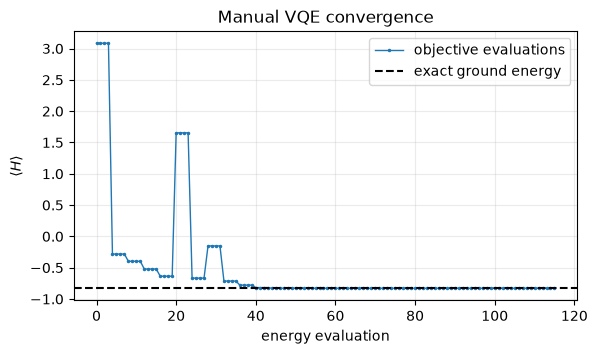

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(history, marker=".", ms=3, lw=1, label="objective evaluations")
ax.axhline(E_exact, color="black", ls="--", label="exact ground energy")
ax.set(xlabel="energy evaluation", ylabel=r"$\langle H\rangle$", title="Manual VQE convergence")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Compare physical observables

Energy agreement alone does not fully validate a variational state, especially near degeneracies. Fidelity and physical observables probe the wavefunction more directly.


In [22]:
print(f"{'observable':<24} {'ED':>14} {'VQE':>14} {'difference':>14}")
for name, operator in [
    ("double occupancy", double_occupancy_op),
    ("spin correlation", spin_correlation_op),
]:
    exact_value = expectation(psi_exact, operator)
    vqe_value = expectation(psi_vqe, operator)
    print(f"{name:<24} {exact_value:>14.8f} {vqe_value:>14.8f} {vqe_value-exact_value:>+14.2e}")

observable                           ED            VQE     difference
double occupancy             0.14644661     0.14644661      +2.95e-09
spin correlation            -0.64016504    -0.64016504      +2.21e-09


## 9. What has been validated?

The calculation now has independent links that agree:

- the fermionic CAR validate the Fock-space sign rule;
- the JW matrices equal the independently constructed fermionic matrices;
- the Pauli sum reconstructs the full $16\times16$ Hamiltonian;
- ED agrees with the analytic two-site energy;
- the VQE energy obeys the variational bound and reaches ED;
- fidelity, double occupancy, and spin correlation validate the state.

### Suggested experiments before moving to Qiskit Nature

1. Change $U/t$ through $0,1,2,4,8,16$ and explain the energy, double occupancy, and spin correlation.
2. Remove the JW $Z$ string and observe exactly which checks fail.
3. Restrict the ansatz to one or two angles and quantify the expressibility error.
4. Replace exact Pauli expectations with finite-shot estimates.
5. Compare several random initial parameters and plot optimizer behavior.

The next notebook can reproduce the same Hamiltonian with Qiskit Nature and require term-by-term, spectrum, and observable agreement with this reference.
